In [1]:
import ase
import matplotlib.pyplot as plt
from ase.io import write,read

import abtem

(examples:4d-stem_quickstart)=
# 4D-STEM quickstart

This notebook demonstrates a basic 4D-stem simulation of MoS<sub>2</sub>.

## Configuration

We start by (optionally) setting our configuration. See [documentation](reference:configuration) for details.

In [2]:
abtem.config.set(
    {
        "device": "cpu",
        "fft": "fftw",
        "diagnostics.task_progress": True,
        "diagnostics.progress_bar": "tqdm",
    }
)

## Atomic model

We create the atomic model. See our [walkthough](walkthrough:atomic_models) or our [tutorial](tutorials:advanced_atomic_models) on atomic models. 

We create an atomic model of silicon using the [`mx2` function](https://wiki.fysik.dtu.dk/ase/ase/build/surface.html#ase.build.mx2) from ASE. The structure is repeated in order to improve the reciprocal space sampling of the simulation.

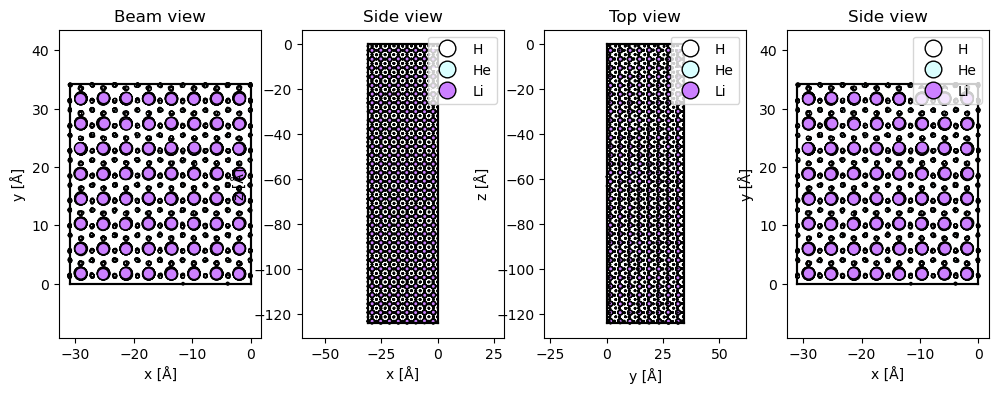

In [4]:
# atoms = ase.build.mx2("WS2", vacuum=2)

# atoms = abtem.orthogonalize_cell(atoms)

# atoms = atoms * (9, 5, 1)
nve_dir = "/media/chenguisen/WD_BLACK/AISI/DeepMD-EM/PbTiO3/293K/supercell_8x9x32/nve"
import glob
from ase.io import read, write
from matplotlib import pyplot as plt
import abtem
import os
snapshots= glob.glob(os.path.join(nve_dir,'*.lammps'))
snapshot = snapshots[0]
atoms = read(snapshot, format='lammps-data')
#atoms.numbers[17] = 14
desired_rotation = 90
rotate_atoms = atoms.copy()
rotate_atoms.rotate(desired_rotation, "y", rotate_cell=True)
rotate_atoms.rotate(desired_rotation, "z", rotate_cell=True)
rotate_atoms.center()
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(12, 4))
abtem.show_atoms(rotate_atoms, ax=ax1, title="Beam view", numbering=False, merge=False)
abtem.show_atoms(rotate_atoms, ax=ax2, plane="xz", title="Side view", legend=True);
abtem.show_atoms(rotate_atoms, ax=ax3, plane="yz", title="Top view", legend=True);
abtem.show_atoms(rotate_atoms, ax=ax4, plane="xy", title="Side view", legend=True);

In [9]:
atoms = rotate_atoms

## Potential

We create an ensemble of potentials using the frozen phonon. See our [walkthrough on frozen phonons](walkthrough:frozen_phonons). 

In [10]:
frozen_phonons = abtem.FrozenPhonons(atoms, 8, sigmas=0.1)

We create a potential from the frozen phonons model, see [walkthrough on potentials](walkthrough:potentials).

In [11]:
potential = abtem.Potential(frozen_phonons, sampling=0.05)

## Wave function

We create a probe wave function at an energy of $80 \ \mathrm{keV}$, an objective aperture of $12 \ \mathrm{mrad}$. See our [walkthrough on wave functions](walkthrough:wave_functions).

Partial temporal coherence is neglected here, see our [tutorial on partial coherence](tutorials:partial_coherence). 

In [12]:
probe = abtem.Probe(energy=300e3, semiangle_cutoff=21.4)
probe.grid.match(potential)

[########################################] | 100% Completed | 202.03 ms
[########################################] | 100% Completed | 101.32 ms


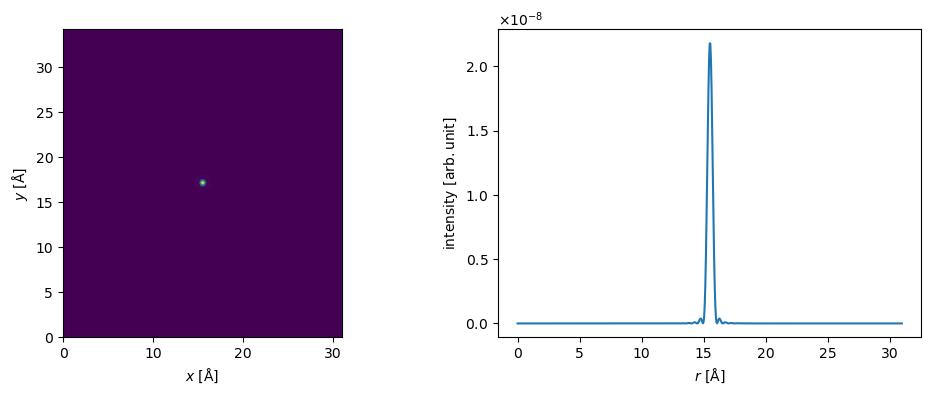

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
probe.show(ax=ax1)
probe.profiles().show(ax=ax2);

## Scan

We select a scan region using fractional coordinates. We scan at the Nyquist frequency, although there is no real reason to do that in a 4D-STEM simulation.

In [14]:
grid_scan = abtem.GridScan(
    start=[0, 0],
    end=[1 / 8, 1 / 8],
    fractional=True,
    potential=potential,
)

## Detect

We use a flexible annular detector, this will let us choose the detector angles after the running multislice.

In [15]:
detector = abtem.PixelatedDetector(to_cpu=True, max_angle=200)

We set up the scanned multislice simulation. See our [walkthrough on scanning and detecting](walkthrough:scan_and_detect).

In [ ]:
measurements = probe.scan(potential, scan=grid_scan, detectors=detector)
measurements.array

dask.array<mean_agg-aggregate, shape=(18, 19, 633, 700), dtype=float32, chunksize=(6, 6, 633, 700), chunktype=numpy.ndarray>

: 

In [11]:
measurements.sampling

(0.03168463396643457, 0.03168463396643457)

We run the simulation directly to disk.

In [12]:
measurements.to_zarr("4d-stem_quickstart.zarr", compute=True)

[                                        ] | 0% Completed | 197.22 us

[########################################] | 100% Completed | 453.96 s


[array([], dtype=float64)]

The data is read back lazily. We load it into memory using `.compute`.

In [13]:
measurements = abtem.from_zarr("4d-stem_quickstart.zarr").compute()

[########################################] | 100% Completed | 614.50 ms


## Post-processing

We can simulate partial spatial coherence by applying a gaussian filter. The standard deviation of the filter is $0.3 \ \mathrm{Å}$, the approximate size of the electron source.

In [28]:
filtered_measurements = measurements.gaussian_source_size(0.1)

Partial temporal coherence is neglected here, see our [tutorial on partial coherence](tutorials:partial_coherence) if you want to include this in your simulation.

In [29]:
noisy_measurements = filtered_measurements.poisson_noise(dose_per_area=1e9)

We show one of the diffraction patterns below. To see the signal outside the bright field disk it may be necessary to block it.

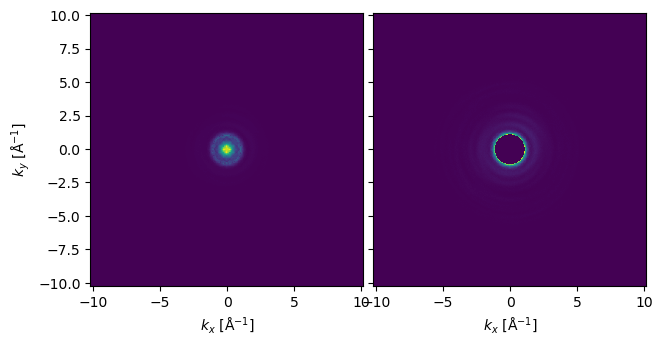

In [30]:
abtem.stack((noisy_measurements[0, 0], noisy_measurements[0, 0].block_direct())).show(
    explode=True, title=None
)

We can show the entire dataset as an exploded plot. If the dataset is large we can use numpy indexing to select every *n*'th diffraction pattern.

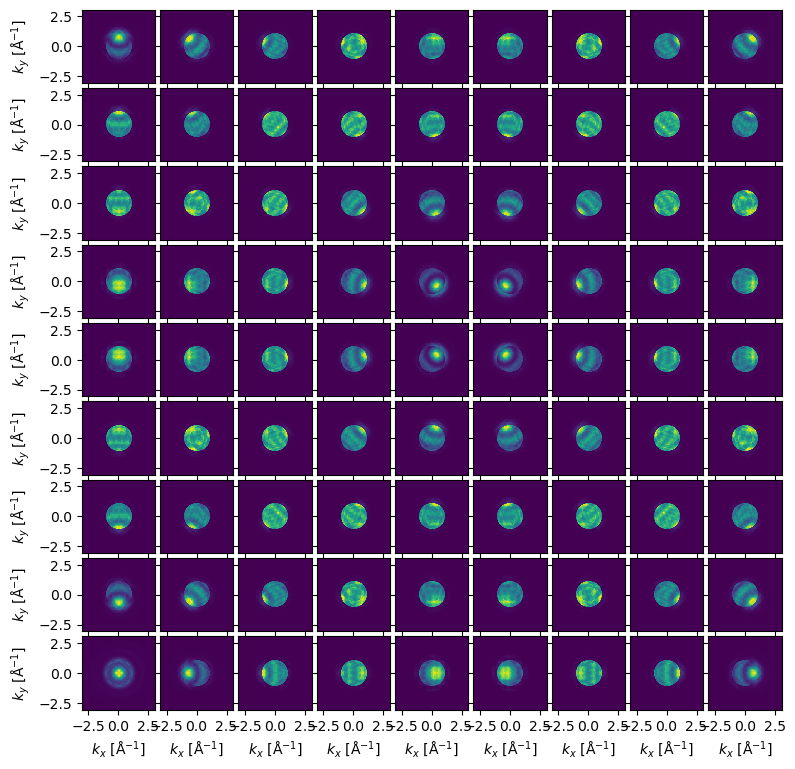

In [31]:
visualization = (
    noisy_measurements[::2, ::2]
    .crop(60)
    .show(explode=True, figsize=(8, 8), title=None)
)
visualization.axes.set_sizes(padding=0.05)

## Reduction

*ab*TEM features a few builtin methods for reducing 4D-stem dataset. For more sophisticated methods, see for example [py4DSTEM](https://github.com/py4dstem/py4DSTEM) or [pyxem](https://github.com/pyxem/pyxem).

We can of course integrate the 4D-STEM dataset to get a ADF signal.

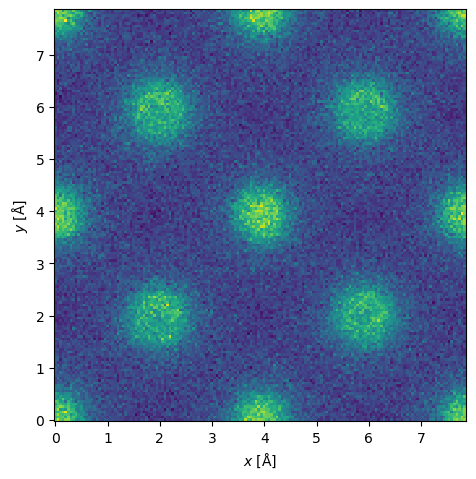

In [36]:
maadf = (
    filtered_measurements.integrate_radial(20, 150)
    .interpolate(0.05)
    .tile((2, 2))
    .poisson_noise(dose_per_area=1e5)
)

maadf.show()

We can get the center of mass and integrated center of mass.

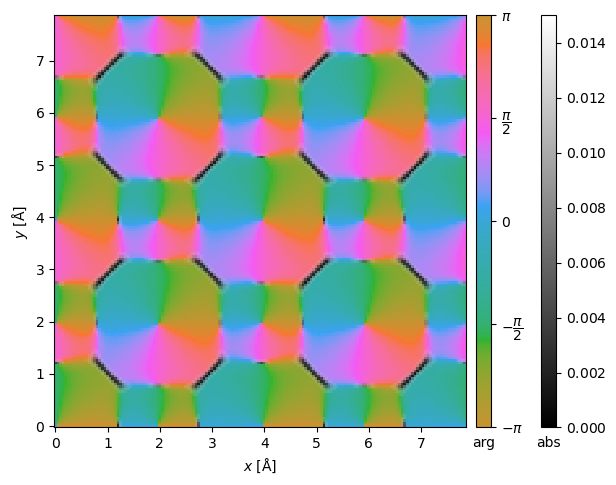

In [37]:
center_of_mass = filtered_measurements.center_of_mass()

interpolated_center_of_mass = center_of_mass.interpolate(0.05).tile((2, 2))

interpolated_center_of_mass.show(cbar=True, vmax=0.015, vmin=0);

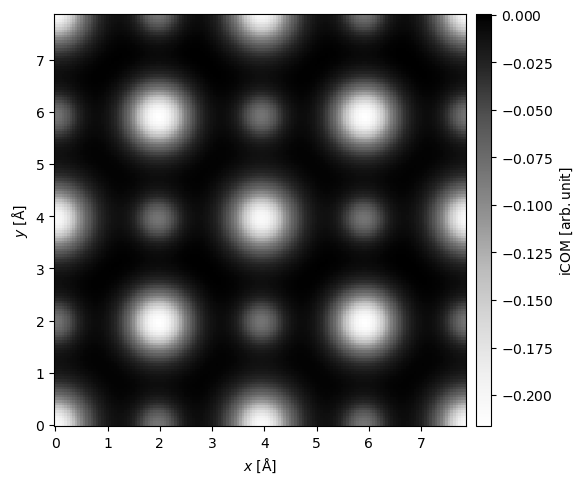

In [61]:
# Compute integrated center-of-mass (iCOM)
integrated_icom = center_of_mass.integrate_gradient()*(-1)
print(integrated_icom)
interpolated_icom = integrated_icom.interpolate(0.05).tile((2, 2))

interpolated_icom.show(cbar=True, cmap='Grays');

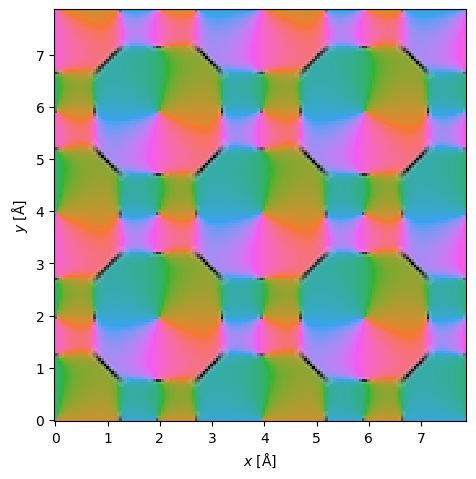

In [21]:
# this cell produces a thumbnail for the online documentation

visualization = interpolated_center_of_mass.show(vmax=0.015, vmin=0.00)
plt.savefig(
    "../thumbnails/4d-stem_quickstart.png",
    bbox_inches="tight",
    pad_inches=0,
)